# Gradient Boosting (XGBoost) — Classificação do Estado do Tabuleiro


## 1. Imports e Carregamento dos Splits


In [363]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier, plot_importance

print("Carregando splits físicos...")
df_train = pd.read_csv('../../data/splits/train.csv')
df_val   = pd.read_csv('../../data/splits/val.csv')
df_test  = pd.read_csv('../../data/splits/test.csv')

X_train, y_train_raw = df_train.drop('classe', axis=1), df_train['classe']
X_val,   y_val_raw   = df_val.drop('classe', axis=1),   df_val['classe']
X_test,  y_test_raw  = df_test.drop('classe', axis=1),  df_test['classe']

# O XGBoost EXIGE classes inteiras sequenciais começando de 0 (0, 1, 2, 3...)
le = LabelEncoder().fit(y_train_raw)
y_train = le.transform(y_train_raw)
y_val   = le.transform(y_val_raw)
y_test  = le.transform(y_test_raw)

print(f"Treino:    {len(X_train):4d} amostras")
print(f"Validação: {len(X_val):4d} amostras")
print(f"Teste:     {len(X_test):4d} amostras")


Carregando splits físicos...
Treino:    1119 amostras
Validação:  241 amostras
Teste:      240 amostras


## 2. Treinamento do Modelo XGBoost

Hiperparâmetros básicos. O conjunto de validação é usado pelo `early_stopping_rounds` para evitar overfitting durante o boosting.


In [364]:
xgb_model = XGBClassifier(
    n_estimators=15,         # Número de árvores sequenciais (com early stopping cuida do excesso), mlogloss cai até 36, acuracia apenas até 15
    learning_rate=1,         # Passo de aprendizado, dataset contem apenas de entre 1,0 e -1, portanto 1 parece mais lógico
    max_depth=4,             # Profundidade máxima de cada árvore (16 posicoes de vitoria (2^4))
    random_state=42,
    eval_metric='mlogloss',  # Métrica de erro para classificação multiclasse
    early_stopping_rounds=3,
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)
print(f"Treinamento encerrado. Melhor iteração: {xgb_model.best_iteration}")


Treinamento encerrado. Melhor iteração: 14


## 3. Avaliação no Conjunto de Validação


=== VALIDAÇÃO ===
Acurácia: 0.9917

              precision    recall  f1-score   support

      Empate       1.00      0.60      0.75         5
    O venceu       1.00      1.00      1.00        48
    Tem jogo       0.98      1.00      0.99        94
    X venceu       1.00      1.00      1.00        94

    accuracy                           0.99       241
   macro avg       0.99      0.90      0.93       241
weighted avg       0.99      0.99      0.99       241



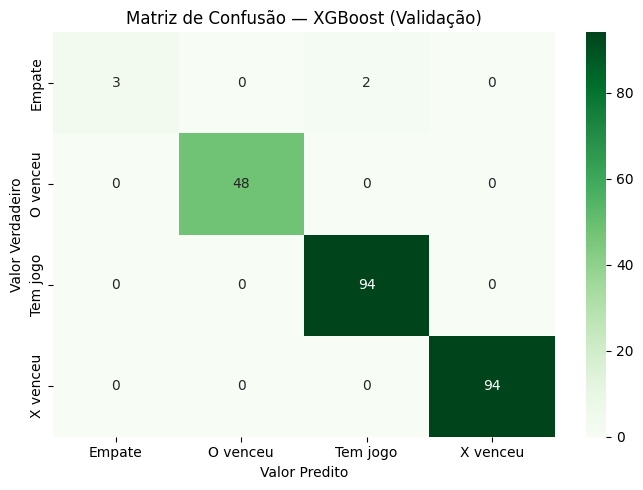

In [365]:
y_val_pred = xgb_model.predict(X_val)

print("=== VALIDAÇÃO ===")
print(f"Acurácia: {accuracy_score(y_val, y_val_pred):.4f}\n")
print(classification_report(y_val, y_val_pred, target_names=le.classes_, zero_division=0))

cm_val = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão — XGBoost (Validação)')
plt.ylabel('Valor Verdadeiro'); plt.xlabel('Valor Predito')
plt.tight_layout(); plt.show()


## 4. Avaliação Final no Conjunto de Teste


=== TESTE ===
Acurácia: 0.9917

              precision    recall  f1-score   support

      Empate       1.00      0.60      0.75         5
    O venceu       1.00      1.00      1.00        47
    Tem jogo       0.98      1.00      0.99        94
    X venceu       1.00      1.00      1.00        94

    accuracy                           0.99       240
   macro avg       0.99      0.90      0.93       240
weighted avg       0.99      0.99      0.99       240



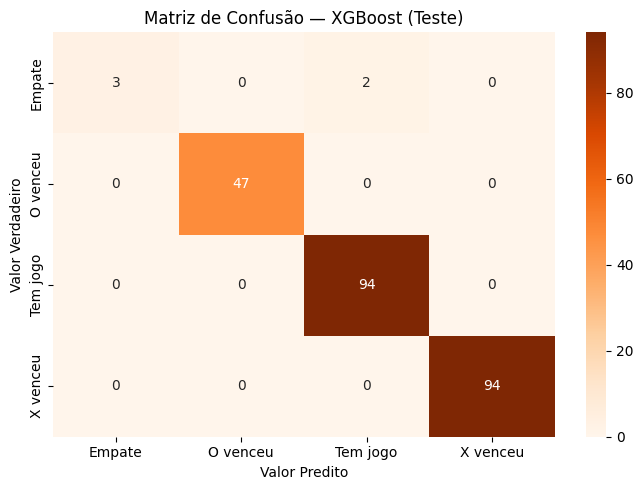

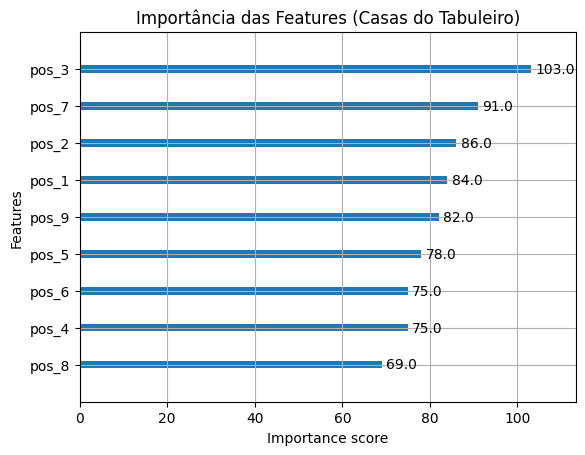

In [366]:
y_test_pred = xgb_model.predict(X_test)

print("=== TESTE ===")
print(f"Acurácia: {accuracy_score(y_test, y_test_pred):.4f}\n")
print(classification_report(y_test, y_test_pred, target_names=le.classes_, zero_division=0))

cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão — XGBoost (Teste)')
plt.ylabel('Valor Verdadeiro'); plt.xlabel('Valor Predito')
plt.tight_layout(); plt.show()

plot_importance(xgb_model, importance_type='weight', title="Importância das Features (Casas do Tabuleiro)")
plt.show()


## 5. Persistência do Modelo


In [367]:
os.makedirs('../../models/GradientBoost', exist_ok=True)
joblib.dump(xgb_model, '../../models/GradientBoost/xgboost_model.pkl')
joblib.dump(le,        '../../models/GradientBoost/label_encoder_xgb.pkl')
print("Modelo salvo com sucesso em: ../../models/GradientBoost")


Modelo salvo com sucesso em: ../../models/GradientBoost
